### Widefield sessions

- load data
- how to do pid
- similar? align, and then decompose
- look at prior paper to see how they handle the loading and other things
- download one eid to test the pipeline

In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
from one.api import ONE
from pathlib import Path
import yaml
import os
import wfield
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
one = ONE()
sessions = one.search(datasets="widefieldU.images.npy")
print(f"{len(sessions)} sessions with widefield data found")

50 sessions with widefield data found


In [4]:
from prior_localization.prepare_data import prepare_widefield

# stim-onset only?
For the ITI, we used frame −2 relative to the stimulus onset. This frame corresponds to a time window of which the start ranges from −198 to −132 ms before the stimulus onset, and of which the end ranges from −132 to −66 ms, depending on the timing of the last frame before stimulus onset. For the post-stimulus interval, we used frame +2, which corresponds to a time window of which the start ranges from 66 to 132 ms from stimulus onset, and extends to 132 to 198 ms after onset. This interval is dependent on the timing of the first frame after stimulus onset, which can occur at anytime between 0 and 66 ms after onset. If there are P pixels and T trials, this selection procedure results in a matrix of size P × T.

In [5]:
# so we can pick frame +1 and +2, aligned on stim-onset
# NOTE: change runpar to prefer threads so that it can actually run

In [6]:
from brainbox.io.one import SessionLoader
from brainwidemap.bwm_loading import load_trials_and_mask
from prior_localization.functions.utils import compute_mask

In [7]:
session_id = sessions[0]
sl = SessionLoader(one, eid=session_id)
sl.load_trials()
trials_mask = compute_mask(
    sl.trials, align_event="stimOn_times", min_rt=0.08, max_rt=None, n_trials_crop_end=1
)

In [8]:
if sum(trials_mask) <= 1:
    raise ValueError(f"Session {session_id} has {sum(trials_mask)} good trials, less than 1.")

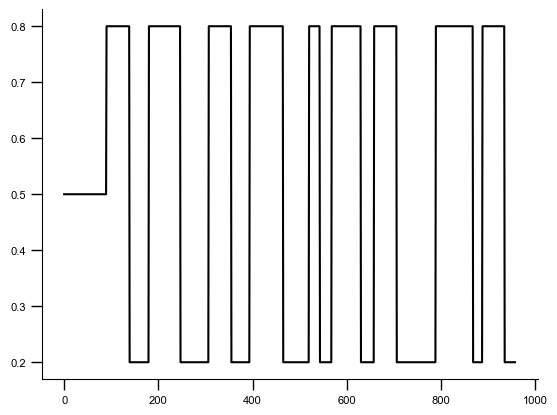

In [9]:
plt.plot(sl.trials.probabilityLeft)

In [13]:
one = ONE(cache_rest=None, mode="remote")

In [16]:
# try the other one

trials, mask = load_trials_and_mask(
    one,
    session_id,
    sess_loader=sl,
    exclude_nochoice=True,
    exclude_unbiased=True,
)
trials = trials[mask]

hemisphere = ("left", "right")
align_event = "stimOn_times"
min_rt = 0.08
max_rt = None
frame_window = (2, -2)

align_times = trials[align_event].values

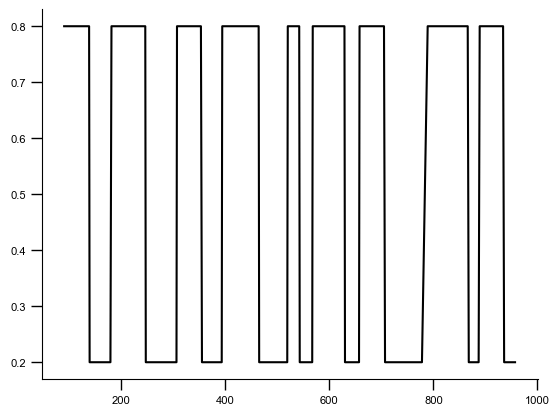

In [17]:
plt.plot(trials.probabilityLeft)

In [94]:
# move to configs
# clean up the code; it is very messy
# streamline everything: maybe next Friday

In [95]:
def check_config():
    """Load config yaml and perform some basic checks"""
    # Get config
    with open(Path(os.getcwd()).parent.joinpath("config.yaml"), "r") as config_yml:
        config = yaml.safe_load(config_yml)
    return config

In [96]:
config = check_config()

In [134]:
data_epoch, actual_regions = prepare_widefield(
    one,
    session_id,
    hemisphere,
    regions="single_regions",
    align_times=sl.trials[align_event].values,
    frame_window=(-3, 3),
    functional_channel=470,
    stage_only=False,
)

In [135]:
data_epoch[0].shape

(958, 7, 155)

In [136]:
data_epoch[1].shape

(958, 7, 7)

In [137]:
from matplotlib import pyplot as plt

In [138]:
# think about discretization

In [140]:
# for idx, r in enumerate(actual_regions):
#     region_means = np.mean(data_epoch[idx], axis=0).T
#     plt.plot(np.mean(region_means, axis=0))
#     plt.fill_between(
#         np.arange(7),
#         np.mean(region_means, axis=0) - np.std(region_means, axis=0) / 2,
#         np.mean(region_means, axis=0) + np.std(region_means, axis=0) / 2,
#         alpha=0.1,
#     )
#     plt.title(r)
#     plt.show()

In [114]:
visp.shape

(958, 3, 243)

In [123]:
visp_means = np.mean(visp, axis=0).T

In [124]:
visp_means.shape

(243, 3)

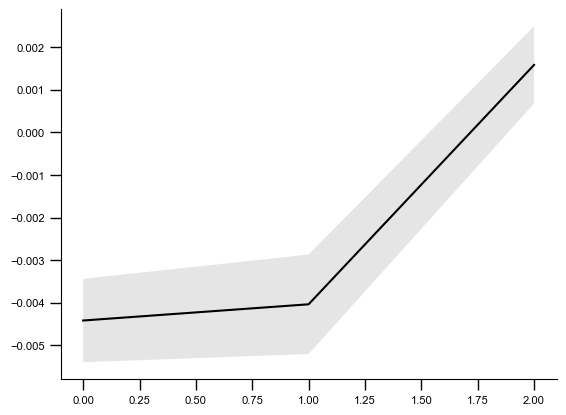

In [131]:
plt.plot(np.mean(visp_means, axis=0))
plt.fill_between(
    np.arange(3),
    np.mean(visp_means, axis=0) - np.std(visp_means, axis=0) / 2,
    np.mean(visp_means, axis=0) + np.std(visp_means, axis=0) / 2,
    alpha=0.1,
)

In [ ]:
from ibl_info.utils import equipopulated_binning

In [154]:
from scipy.stats import zscore

In [163]:
# discretize across neurons or time?

In [165]:
framea = visp[:, 0, :]

In [167]:
framea.shape

(958, 243)

In [171]:
import seaborn as sns

<Axes: >

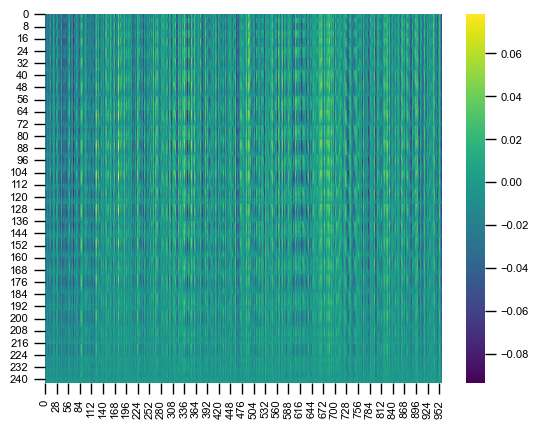

In [173]:
sns.heatmap(framea.T, cmap="viridis")

In [ ]:
framea_disc = [equipopulated_binning(x, n_bins=3) for x in framea.T]

In [190]:
framea_disc = np.asarray(framea_disc)

<Axes: >

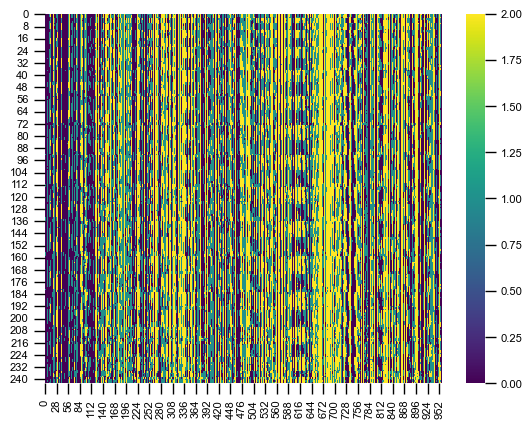

In [191]:
sns.heatmap(framea_disc, cmap="viridis")

In [192]:
from scipy.stats import kendalltau

In [194]:
# should be very redundant (idk?)

In [195]:
# widefield loading is easier imo
# not so many quality checks
# should take longer; more voxels
# use 5 bins for now
# oh we need to do the same all v cong v incong binning
# maybe we can clean it up
# prepare behavior and prepare widefield
# prepare widefield loads things up into arrays to directly do pid/mi
# eid -> all regions -> pid/mi

- equipopulated binning maximizes the amount of information :)
- also : normalize the activity of each neuron across trials.
- equipopulated binning at global level : before splitting it up by trials
- just set negative values to 0 if we do a lot of repeats
- shuffle corrections : how hard is it to get pseudosessions?

In [201]:
from brainbox.task.closed_loop import generate_pseudo_session

In [6]:
import warnings

warnings.filterwarnings("ignore")

In [207]:
pseudo = generate_pseudo_session(trials=sl.trials, generate_choices=True)

In [4]:
import itertools
import concurrent.futures
from joblib import Parallel, delayed
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.discriminant_analysis import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import compute_sample_weight
from tqdm import tqdm
from ibl_info.decoder_pid import compute_decoder_pid
from ibl_info.dual_decoders import compute_null_distribution
from ibl_info.prepare_data_pid import get_new_cinc_intervals, get_new_cinc_intervals_choice
from ibl_info.utils import check_config, epoch_events
from one.api import ONE
from prior_localization.prepare_data import prepare_widefield
from brainbox.io.one import SessionLoader
from brainwidemap.bwm_loading import load_trials_and_mask
import numpy as np
import pickle as pkl
import os

config = check_config()

In [5]:
from ibl_info.prepare_data_pid import get_new_cinc_intervals, get_new_cinc_intervals_choice
from ibl_info.utils import epoch_events

epoch = "stim"
eid = sessions[0]
align_event = epoch_events("stim")  # should default to stimon
sl = SessionLoader(one, eid=eid)
trials, mask = load_trials_and_mask(
    one,
    eid,
    sess_loader=sl,  # using session loader to load trials so that we get proper probability
    exclude_nochoice=True,
    exclude_unbiased=True,
)
trials = trials[mask]
align_times = trials[align_event].values

if epoch == "stim":
    intervals, target_variable, congruent_flags, incongruent_flags = get_new_cinc_intervals(
        trials, epoch
    )
elif epoch == "choice":
    intervals, target_variable, congruent_flags, incongruent_flags = get_new_cinc_intervals_choice(
        trials, epoch
    )

# remember there are pairs of regions now
all_regions = config["widefield_regions"]
data_epoch, actual_regions = prepare_widefield(
    one,
    eid,
    hemisphere=config["hemisphere"],
    regions=all_regions,
    align_times=align_times,
    frame_window=config["frames"],
    functional_channel=470,
    stage_only=False,
)

/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:117: RuntimeWarning: divide by zero encountered in matmul
  res = (nM @ xy).T
/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:117: RuntimeWarning: overflow encountered in matmul
  res = (nM @ xy).T
/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:117: RuntimeWarning: invalid value encountered in matmul
  res = (nM @ xy).T
/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:404: RuntimeWarning: divide by zero encountered in matmul
  t = self.Uflat[idx,:]@self.SVT
/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:404: RuntimeWarning: overflow encountered in matmul
  t = self.Uflat[idx,:]@self.SVT
/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:404: RuntimeWarning: invalid value encountered in matmul
  t = self.Uflat[idx,:]@self.SVT


In [17]:
from ibl_info.decoder_pid_wifi import check_minimum


total_frames = data_epoch[0].shape[1]  # type: ignore


region_a_idx = 0
region_b_idx = 1

region_a = data_epoch[region_a_idx][0, :].T
region_b = data_epoch[region_b_idx][0, :].T

key = f"{used_regions[region_a_idx]}_{used_regions[region_b_idx]}"

null_results = compute_null_distribution(
    neural_data_A=region_a,
    neural_data_B=region_b,
    trial_labels=target_variable,
    subset_size_D=config["wifi_subset"],
    n_permutations=config["n_bootstraps_decoding"],
)

Generating Null Distribution (50 permutations)...
